# Pretrained ResNet18 - 阈值起振

1. 采用**分层采样**：“每个手指固定 6 张训练、2 张测试”
能确保模型在训练时见过每一个手指，在测试时也能评估每一个手指。
2. 训练集：测试集 = 6:2，保持了合理的训练数据量，同时保证了测试的代表性。
3. **使用LR=0.001并进行学习率衰退**

**Result: %的测试准确率**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from PIL import Image

from torch.utils.data import Subset
from collections import defaultdict
import random

In [3]:
DATA_DIR = '../../FVC2002/Db1'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda')

## 1. 读取指纹数据

In [5]:
class FVC2002Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # 过滤出所有的 .tif 文件
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # 加载图像并转为灰度图（指纹图通常是单通道）
        image = Image.open(img_path).convert('L')
        
        # 解析标签：例如 "10_3.tif" -> 标签为 10
        # 注意：类别索引通常从 0 开始，所以我们将 ID 减 1
        label = int(img_name.split('_')[0]) - 1
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [6]:
# 临时加载数据集（仅 ToTensor）
dataset = FVC2002Dataset(root_dir=DATA_DIR,
                        transform=transforms.Compose([
                        transforms.Grayscale(),
                        transforms.ToTensor()
                               ]))
loader = DataLoader(dataset, batch_size=100, shuffle=False)

def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0
    for images, _ in loader:
        image_count_in_batch = images.size(0)
        images = images.view(image_count_in_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += image_count_in_batch
    mean /= total_images_count
    std /= total_images_count
    return mean, std

mean, std = get_mean_and_std(loader)
print(f"Mean: {mean}, Std: {std}")

Mean: tensor([0.8499]), Std: tensor([0.2375])


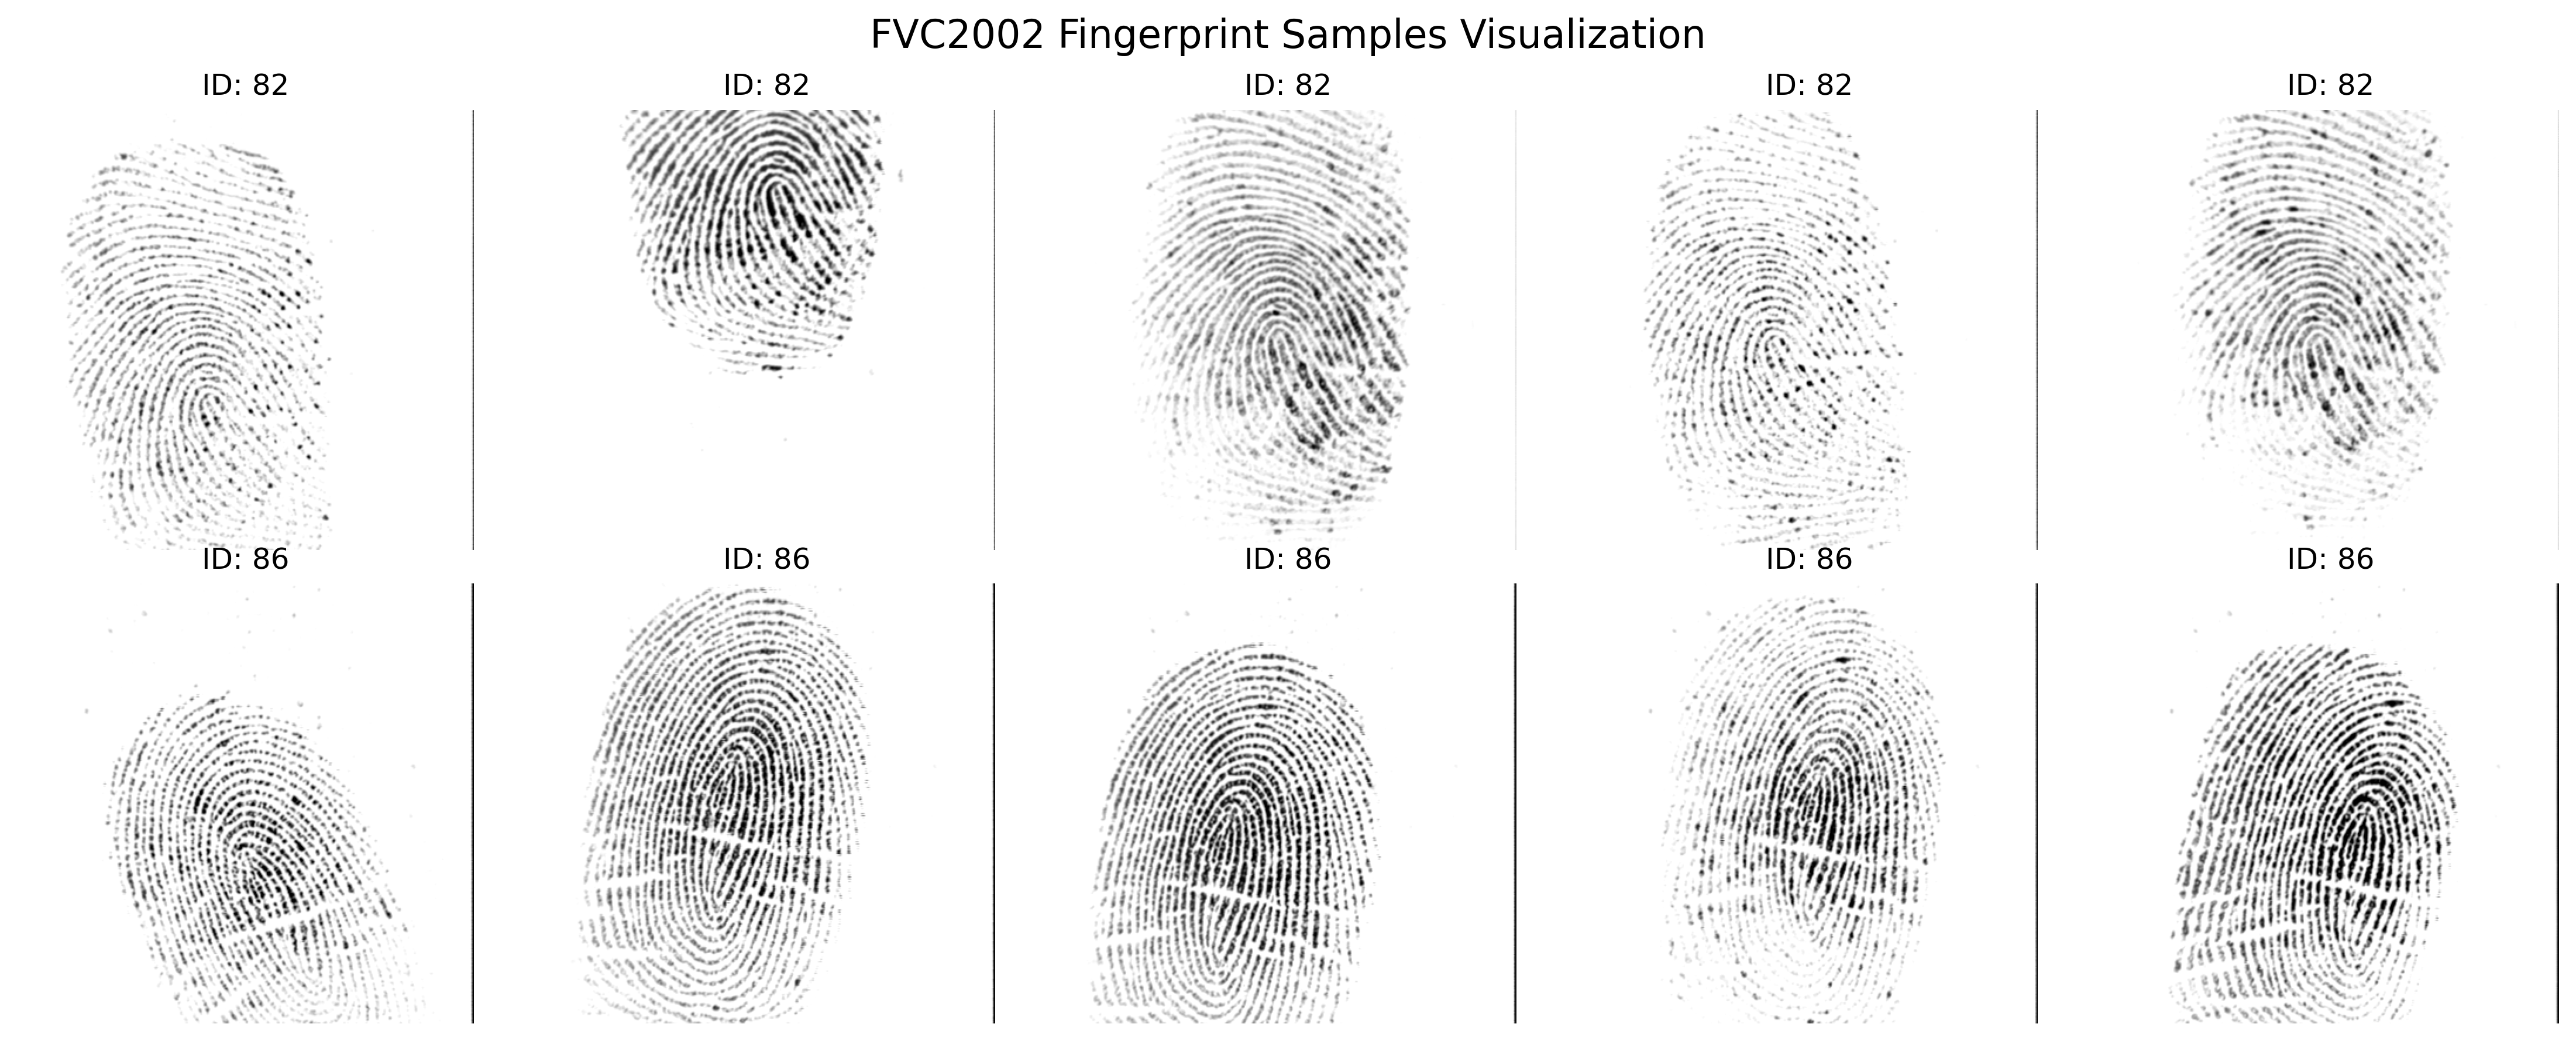

In [7]:
# 指纹图片查看
def visualize_fvc_samples(dataset, num_people=2, samples_per_person=5):
    # 1. 建立 ID 到 索引列表的映射
    # label 是 img_name.split('_')[0] - 1
    id_to_indices = {}
    for idx, img_name in enumerate(dataset.image_files):
        label = int(img_name.split('_')[0]) - 1
        if label not in id_to_indices:
            id_to_indices[label] = []
        id_to_indices[label].append(idx)

    # 2. 随机抽取指定数量的人
    selected_ids = random.sample(list(id_to_indices.keys()), num_people)

    # 3. 开始绘图
    fig, axes = plt.subplots(num_people, samples_per_person, figsize=(15, 6), dpi=300)
    fig.suptitle('FVC2002 Fingerprint Samples Visualization', fontsize=16)

    for i, person_id in enumerate(selected_ids):
        # 随机抽取该人的 5 个指纹索引
        indices = random.sample(id_to_indices[person_id], samples_per_person)
        
        for j, idx in enumerate(indices):
            image, label = dataset[idx]
            
            # 如果 image 是 Tensor (经过了 transform)，需要转回 numpy
            if torch.is_tensor(image):
                image = image.squeeze().numpy() # 移除通道维度 [1, H, W] -> [H, W]
            
            ax = axes[i, j] if num_people > 1 else axes[j]
            ax.imshow(image, cmap='gray')
            ax.set_title(f"ID: {person_id + 1}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# 使用方法：
visualize_fvc_samples(dataset, num_people=2, samples_per_person=5)

### 设定阈值后指纹图像变化

- 由于我们采用的是压力传感器采集，因此压力较大的区域（即纹线）会有较低的像素值（黑色），而压力较小的区域（即背景）会有较高的像素值（白色）。
- 因此，根据压力小于阈值时，氧化铌器件不起振，我们可以将像素值高于某个阈值的区域设为1（表示背景）

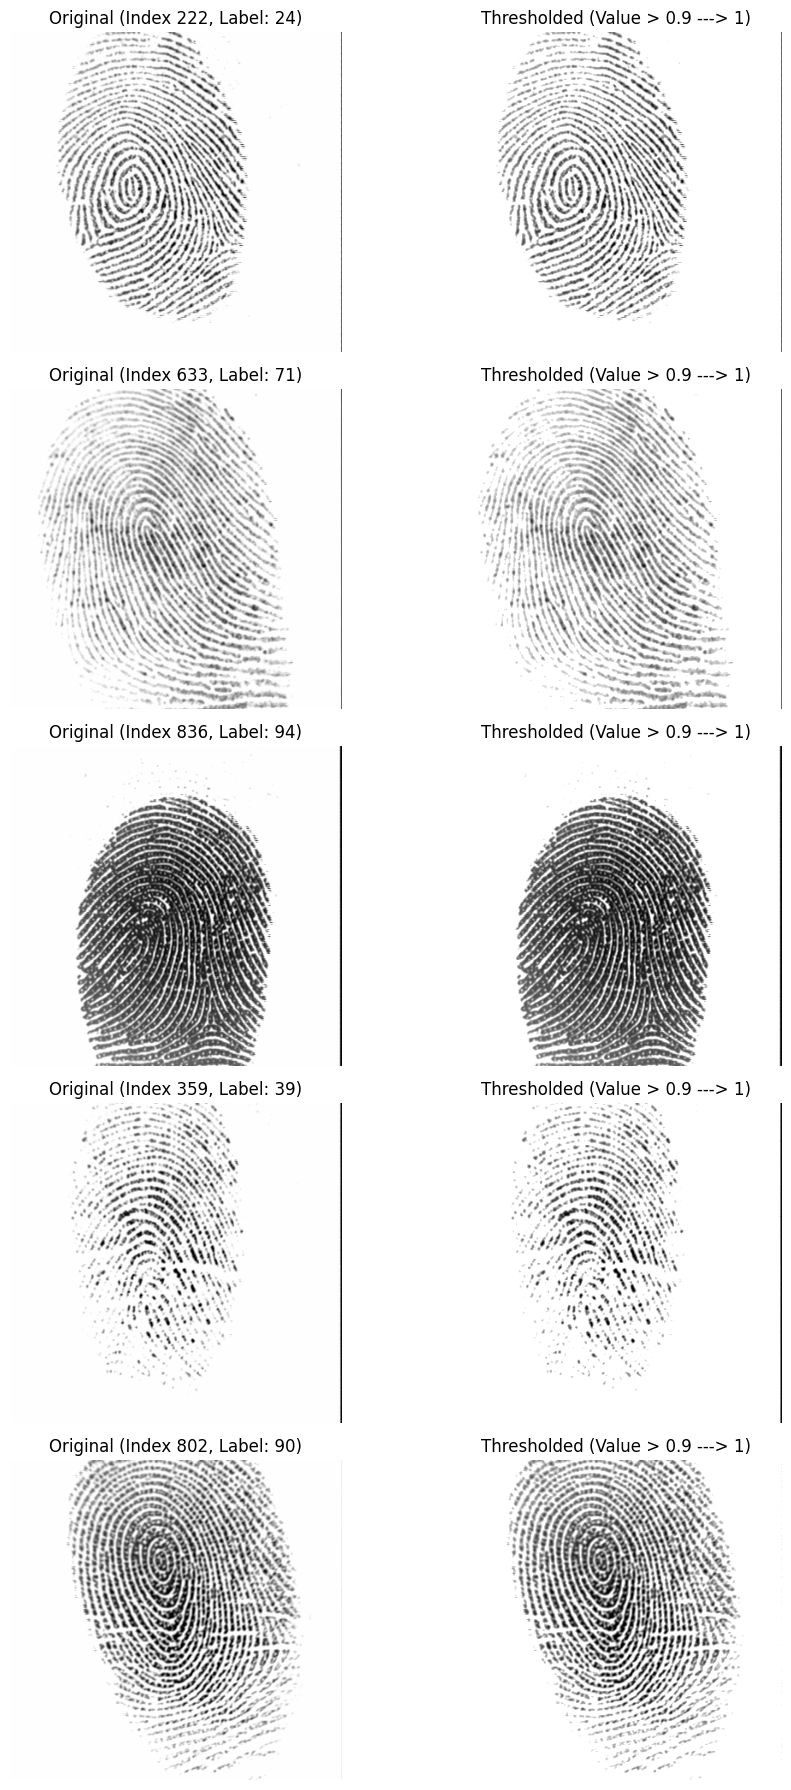

In [20]:
# 1. 设定阈值 (范围 0 到 1，因为 ToTensor 已将像素归一化)
THRESHOLD = 0.9

# 2. 随机取出 5 个索引
indices = random.sample(range(len(dataset)), 5)

# 3. 创建画布 (5行2列：左侧原图，右侧处理后的图)
fig, axes = plt.subplots(5, 2, figsize=(10, 18))

for i, idx in enumerate(indices):
    # 获取原始图像 Tensor [1, H, W]
    img_tensor, label = dataset[idx]
    
    # 复制一份用于阈值处理
    # 逻辑：将像素值大于 THRESHOLD 的位置设为 1
    thresholded_tensor = img_tensor.clone()
    thresholded_tensor[thresholded_tensor > THRESHOLD] = 1
    
    # 将 Tensor 转换为 Numpy 以便绘图 [H, W]
    orig_np = img_tensor.squeeze().numpy()
    thresh_np = thresholded_tensor.squeeze().numpy()
    
    # 绘制原始图
    axes[i, 0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Original (Index {idx}, Label: {label})")
    axes[i, 0].axis('off')
    
    # 绘制阈值处理后的图
    axes[i, 1].imshow(thresh_np, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Thresholded (Value > {THRESHOLD} ---> 1)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
class ApplyTransform(Dataset):
    """
    一个简单的装饰器类，用于给 Subset 应用特定的 transform
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. 定义两个不同的 Pipeline
# 基础操作（训练和测试共有）
base_ops = [
    transforms.CenterCrop(320),  # 中心裁剪到320x320
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # --- 核心修改：仅修改大于阈值的像素 ---
    # 逻辑：如果 x > THRESHOLD，设为 1.0；否则保留原值 x
    transforms.Lambda(lambda x: torch.where(x > THRESHOLD, torch.ones_like(x), x)),
    transforms.Normalize(mean=[0.85], std=[0.2547])     # 标准差变化
]

# 训练集特有：加入随机旋转
train_transforms = transforms.Compose([
    transforms.RandomRotation(25, fill=(255,)),  # 随机旋转 ±25 度，空白处填充白色
    *base_ops
])

# 测试集：仅基础操作
test_transforms = transforms.Compose(base_ops)

# 2. 原始数据集加载时不带 transform (或者只带 Resize)
full_dataset = FVC2002Dataset(root_dir=DATA_DIR, transform=None)

# --- 2. 建立标签到索引的映射 (字典结构) ---
# 这一步是为了找出每个手指对应的 8 张图分别在列表的哪个位置
label_to_indices = defaultdict(list)
for idx, img_name in enumerate(full_dataset.image_files):
    # 使用与你 Dataset 类中一致的解析逻辑
    label = int(img_name.split('_')[0]) - 1
    label_to_indices[label].append(idx)

train_indices = []
test_indices = []

# --- 3. 核心：对每一个类别固定分配 6/2 ---
# 确保每个类（手指）都参与了划分
for label, indices in label_to_indices.items():
    # 随机打乱当前手指的 8 张图索引
    random.shuffle(indices)
    
    # 取前 6 张作为训练，后 2 张作为测试
    train_indices.extend(indices[:6])
    test_indices.extend(indices[6:])

# --- 4. 创建 Subset 并应用不同的 Transform ---
# 先利用索引创建子集
train_subset = Subset(full_dataset, train_indices)
test_subset = Subset(full_dataset, test_indices)
# 5. 分别包装，应用不同的 transform
train_dataset = ApplyTransform(train_subset, transform=train_transforms)
test_dataset = ApplyTransform(test_subset, transform=test_transforms)

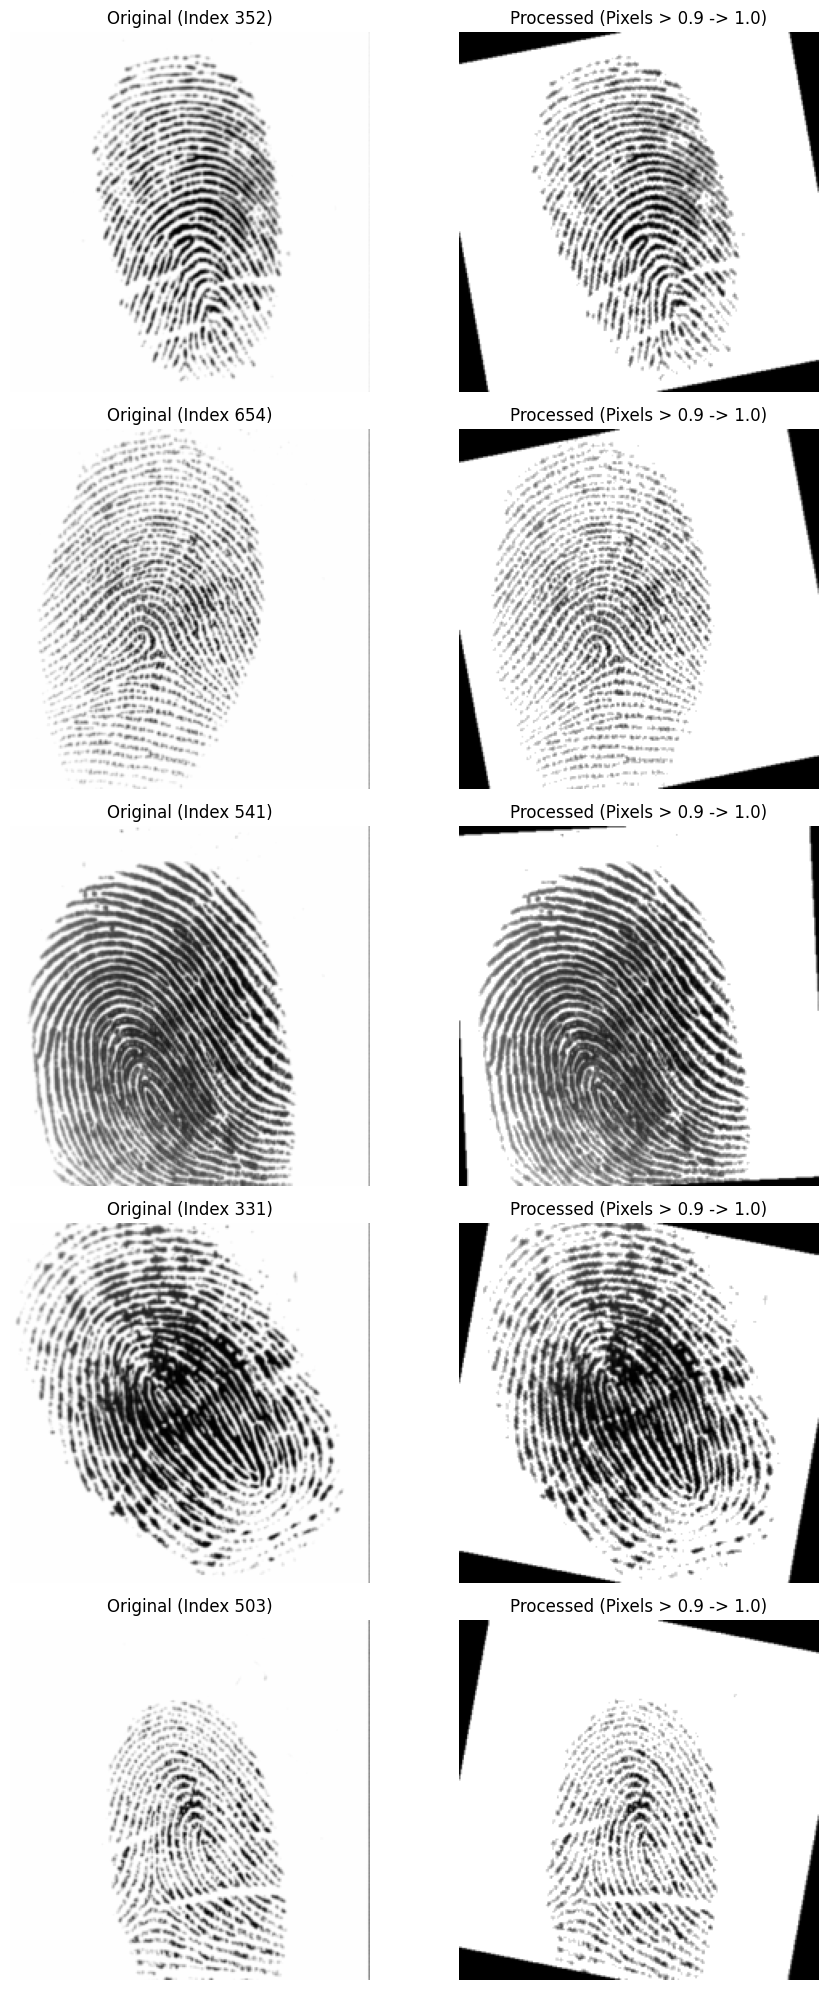

In [32]:
def denormalize(tensor, mean=0.85, std=0.2375):
    # 逆运算：y * std + mean
    return tensor * std + mean

# 随机选 5 个索引
sample_indices = random.sample(range(len(train_dataset)), 5)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, idx in enumerate(sample_indices):
    # 1. 获取处理后的图像 (从 train_dataset，注意解包元组)
    img_processed, label = train_dataset[idx]
    
    # 2. 获取原始图像 (从 full_dataset 拿原始 Tensor 对比)
    # 注意：full_dataset 里的索引需要通过 train_indices 转换回去
    raw_idx = train_indices[idx]
    raw_img_pil, _ = full_dataset[raw_idx]
    # 简单处理以便对比
    raw_tensor = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])(raw_img_pil)

    # 绘制原始图
    axes[i, 0].imshow(raw_tensor.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Original (Index {raw_idx})")
    
    # 绘制处理后的图 (高亮部分被置为 1)
    # 注意：如果后续有 Normalize，绘图时可能需要反归一化或手动设置 vmin/vmax
    
    axes[i, 1].imshow(denormalize(img_processed.squeeze()), cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Processed (Pixels > {THRESHOLD} -> 1.0)")
    
    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [33]:
len(train_dataset), len(test_dataset)

(660, 220)

In [34]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2. 构建模型

### 2.1 ResNet 18

### 2.1.1 调用官方预训练模型

In [10]:
def get_model(num_classes=110): # FVC2002 DB1 通常是 110 类
    # 1. 加载预训练模型
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # 2. 保存原始的 conv1 权重
    original_conv1 = model.conv1
    
    # 3. 创建新的单通道 conv1
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    
    # 4. 【核心改进】将 3 通道权重合并到 1 通道，而不是随机初始化
    # 将 RGB 权重的均值赋给单通道
    with torch.no_grad():
        model.conv1.weight.data = original_conv1.weight.data.sum(dim=1, keepdim=True)
    
    # 5. 修改全连接层
    num_ftrs = model.fc.in_features
    
    # 针对小数据集，建议在 FC 层前加个 Dropout 防止过拟合
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model

## 3. 模型训练

In [11]:
# 1. 训练一个 Epoch 的函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

In [11]:
# 2. 验证/测试函数 (基于你提供的 evaluate 修改)
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / len(loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [20]:
# 3. 总训练控制函数
def train(model, train_loader, test_loader, criterion, optimizer, device, scheduler=None, epochs=20):
    # 用于记录历史数据以便绘图
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    print(f"开始训练，设备: {device}")
    for epoch in range(epochs):
        # 训练阶段
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        # 验证阶段
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        
        # 每个 epoch 结束更新学习率
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_acc)  # 以验证准确率为指标调整学习率
            else:
                scheduler.step()  # 其他类型的调度器直接调用 step()
            current_lr = optimizer.param_groups[0]['lr']

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"[Epoch {epoch+1}/{epochs}](LR: {current_lr:.6f}) -> "
              f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}% | "
              f"Train Loss: {train_loss:.4f}")

    # 训练结束后进行可视化
    plot_history(history)
    return history

# 4. 可视化函数
def plot_history(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # 绘制损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### 3.1 ResNet18

### 3.1.1 预训练模型

##### 余弦退火

总参数量: 11,226,670
开始训练，设备: cuda
[Epoch 1/100](LR: 0.001000) -> Train Acc: 0.76%, Test Acc: 0.91% | Train Loss: 5.0726
[Epoch 2/100](LR: 0.000999) -> Train Acc: 1.21%, Test Acc: 2.73% | Train Loss: 4.7396
[Epoch 3/100](LR: 0.000998) -> Train Acc: 4.24%, Test Acc: 10.45% | Train Loss: 4.3851
[Epoch 4/100](LR: 0.000996) -> Train Acc: 11.52%, Test Acc: 14.09% | Train Loss: 3.7019
[Epoch 5/100](LR: 0.000994) -> Train Acc: 21.36%, Test Acc: 30.00% | Train Loss: 3.1618
[Epoch 6/100](LR: 0.000991) -> Train Acc: 33.33%, Test Acc: 32.73% | Train Loss: 2.5647
[Epoch 7/100](LR: 0.000988) -> Train Acc: 48.03%, Test Acc: 41.36% | Train Loss: 2.1259
[Epoch 8/100](LR: 0.000984) -> Train Acc: 58.18%, Test Acc: 55.91% | Train Loss: 1.7716
[Epoch 9/100](LR: 0.000980) -> Train Acc: 64.24%, Test Acc: 58.64% | Train Loss: 1.4763
[Epoch 10/100](LR: 0.000976) -> Train Acc: 70.15%, Test Acc: 56.82% | Train Loss: 1.2502
[Epoch 11/100](LR: 0.000971) -> Train Acc: 78.79%, Test Acc: 61.82% | Train Loss: 1.0233
[Epo

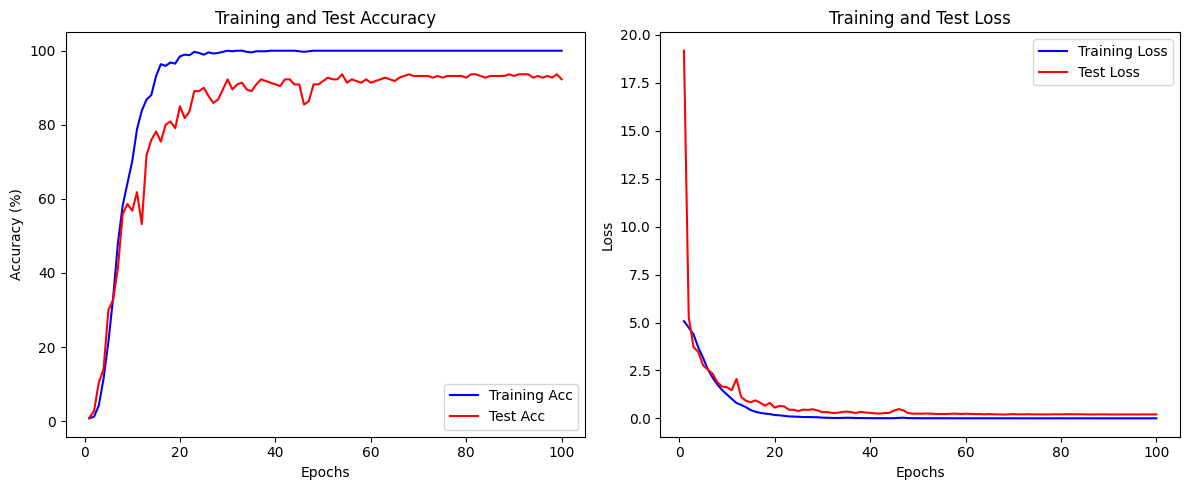

In [19]:
resnet_pretrained = get_model(num_classes=110).to(device)
optimizer = optim.Adam(resnet_pretrained.parameters(), lr=0.001)
# 进行学习率衰退, 使用CosineAnnealingLR
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in resnet_pretrained.parameters())
print(f"总参数量: {total_params:,}")
history1 = train(resnet_pretrained, train_loader, test_loader, criterion, optimizer, device, scheduler, epochs=100)

##### ReduceLROnPlateau

总参数量: 11,226,670
开始训练，设备: cuda
[Epoch 1/100](LR: 0.001000) -> Train Acc: 3.03%, Test Acc: 1.82% | Train Loss: 4.9873
[Epoch 2/100](LR: 0.001000) -> Train Acc: 7.58%, Test Acc: 5.45% | Train Loss: 4.1515
[Epoch 3/100](LR: 0.001000) -> Train Acc: 17.73%, Test Acc: 22.27% | Train Loss: 3.4965
[Epoch 4/100](LR: 0.001000) -> Train Acc: 24.55%, Test Acc: 25.45% | Train Loss: 2.9959
[Epoch 5/100](LR: 0.001000) -> Train Acc: 40.15%, Test Acc: 33.18% | Train Loss: 2.4359
[Epoch 6/100](LR: 0.001000) -> Train Acc: 52.12%, Test Acc: 41.82% | Train Loss: 1.9770
[Epoch 7/100](LR: 0.001000) -> Train Acc: 62.58%, Test Acc: 50.00% | Train Loss: 1.6356
[Epoch 8/100](LR: 0.001000) -> Train Acc: 69.24%, Test Acc: 54.09% | Train Loss: 1.3271
[Epoch 9/100](LR: 0.001000) -> Train Acc: 78.79%, Test Acc: 64.55% | Train Loss: 1.0189
[Epoch 10/100](LR: 0.001000) -> Train Acc: 83.33%, Test Acc: 61.82% | Train Loss: 0.8284
[Epoch 11/100](LR: 0.001000) -> Train Acc: 87.73%, Test Acc: 78.64% | Train Loss: 0.6699
[Ep

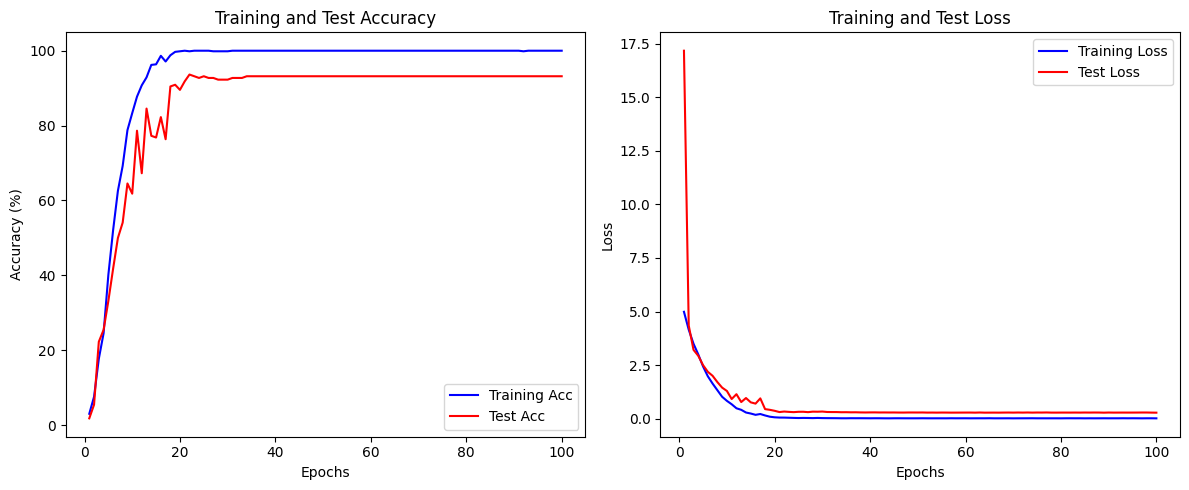

In [21]:
resnet_pretrained = get_model(num_classes=110).to(device)
optimizer = optim.Adam(resnet_pretrained.parameters(), lr=0.001)
# 进行学习率衰退, 使用CosineAnnealingLR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in resnet_pretrained.parameters())
print(f"总参数量: {total_params:,}")
history2 = train(resnet_pretrained, train_loader, test_loader, criterion, optimizer, device, scheduler, epochs=100)